# SHINE_SWE_DISTILLATION Dataset Analysis

This notebook provides comprehensive analysis of the SHINE_SWE_DISTILLATION dataset:
1. **Dataset Overview**: Number of shards, samples per shard, data schema
2. **Repo Statistics**: Number of repos, trajectories per repo, correctness breakdown
3. **Token Length Distribution**: Using Qwen3.6-27B tokenizer with parallel processing
   - Per shard / per repo / per role (system, user, assistant)
   - Summary tables with mean, max, min

In [3]:
import json
import os
import sys
import time
import re
from pathlib import Path
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from multiprocessing import cpu_count
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.figsize'] = (14, 6)
matplotlib.rcParams['figure.dpi'] = 100

DATA_DIR = Path('/apdcephfs_zwfy/share_303937731/xiyuanwang/liuyewei/SHINE_V2_tmp/data/SHINE_SWE_DISTILLATION')
MODEL_DIR = '../models/Qwen3.6-27B'

# Find all shard directories (Arrow IPC stream format)
shard_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
print(f'Data directory: {DATA_DIR}')
print(f'Number of shards: {len(shard_dirs)}')
for d in shard_dirs:
    arrow_files = list(d.glob('*.arrow'))
    total_size = sum(f.stat().st_size for f in arrow_files)
    size_str = f'{total_size/1e9:.2f} GB' if total_size > 1e9 else f'{total_size/1e6:.2f} MB'
    print(f'  {d.name:<75} {size_str}')

Data directory: /apdcephfs_zwfy/share_303937731/xiyuanwang/liuyewei/SHINE_V2_tmp/data/SHINE_SWE_DISTILLATION
Number of shards: 3
  qwen36_smith_full_shard0_of4_20260602.resolved.openai_qwen36                773.91 MB
  qwen36_smith_full_shard1_of4_20260602.resolved.openai_qwen36                767.95 MB
  qwen36_smith_full_shard2_of4_20260602.resolved.openai_qwen36                777.54 MB


## 1. Load Dataset

The SHINE_SWE_DISTILLATION dataset is stored in HuggingFace datasets Arrow format.
Each shard is a separate directory containing Arrow data files.

In [4]:
import pyarrow as pa
import pyarrow.ipc as ipc

def load_all_shards(data_dir):
    """Load all shard datasets from HuggingFace Arrow format and concatenate them.
    
    Each shard directory contains Arrow IPC file(s) (data-XXXXX-of-YYYYY.arrow).
    We use memory-mapped reading for efficiency.
    """
    shard_dirs = sorted([d for d in data_dir.iterdir() if d.is_dir() and not d.name.startswith('.')])
    tables = []
    shard_names_list = []
    
    for shard_dir in shard_dirs:
        print(f'  Loading shard: {shard_dir.name}...')
        arrow_files = sorted(shard_dir.glob('*.arrow'))
        if not arrow_files:
            print(f'    -> No arrow files found, skipping.')
            continue
        try:
            shard_tables = []
            for arrow_file in arrow_files:
                # HuggingFace datasets uses Arrow IPC Stream format
                reader = ipc.open_stream(str(arrow_file))
                shard_tables.append(reader.read_all())
            table = pa.concat_tables(shard_tables) if len(shard_tables) > 1 else shard_tables[0]
            # Add shard_name column
            shard_name_col = pa.array([shard_dir.name] * table.num_rows, type=pa.string())
            table = table.append_column('shard_name', shard_name_col)
            tables.append(table)
            shard_names_list.append(shard_dir.name)
            print(f'    -> {table.num_rows:,} samples loaded')
        except Exception as e:
            print(f'    -> ERROR loading shard: {e}')
            continue
    
    if not tables:
        raise RuntimeError('No shards could be loaded! Please ensure data is downloaded.')
    
    # Concatenate all shards into one PyArrow Table
    full_table = pa.concat_tables(tables, promote_options='default')
    print(f'\nTotal samples loaded: {full_table.num_rows:,}')
    return full_table, shard_names_list

print('Loading dataset shards...')
full_table, shard_names_loaded = load_all_shards(DATA_DIR)

# Convert to list of dicts for easy access
print('\nConverting to records...')
full_dataset = full_table.to_pylist()
print(f'Conversion done. {len(full_dataset):,} records.')

# Show dataset schema
print(f'\nDataset schema:')
for field in full_table.schema:
    print(f'  {field.name}: {field.type}')
print(f'\nFirst sample keys: {list(full_dataset[0].keys())}')

Loading dataset shards...
  Loading shard: qwen36_smith_full_shard0_of4_20260602.resolved.openai_qwen36...
    -> 6,588 samples loaded
  Loading shard: qwen36_smith_full_shard1_of4_20260602.resolved.openai_qwen36...
    -> 6,490 samples loaded
  Loading shard: qwen36_smith_full_shard2_of4_20260602.resolved.openai_qwen36...
    -> 6,520 samples loaded

Total samples loaded: 19,598

Converting to records...
Conversion done. 19,598 records.

Dataset schema:
  messages: list<item: struct<role: string, content: string, reasoning_content: string, name: string, tool_call_id: string, tool_calls: list<item: struct<id: string, type: string, function: struct<name: string, arguments: string>>>>>
  source_dataset: string
  repo: string
  correctness: string
  instance_id: string
  traj_id: string
  model: string
  tools: list<item: struct<type: string, function: struct<name: string, description: string, parameters: struct<type: string, properties: extension<arrow.json>, required: list<item: string>

In [5]:
# Inspect a sample to understand the data structure
sample = full_dataset[0]
print('=== Sample Structure ===')
for key, value in sample.items():
    if key == 'messages':
        msgs = value or []
        print(f'  {key}: list of {len(msgs)} messages')
        for i, msg in enumerate(msgs[:3]):
            role = msg.get('role', 'unknown')
            content = msg.get('content') or ''
            print(f'    [{i}] role={role}, content_len={len(content)}')
        if len(msgs) > 3:
            print(f'    ... ({len(msgs) - 3} more messages)')
    elif key == 'tools':
        if value:
            print(f'  {key}: list of {len(value)} tools')
        else:
            print(f'  {key}: {value}')
    elif isinstance(value, str) and len(value) > 100:
        print(f'  {key}: "{value[:100]}..." (len={len(value)})')
    else:
        print(f'  {key}: {value}')

=== Sample Structure ===
  messages: list of 70 messages
    [0] role=system, content_len=77
    [1] role=user, content_len=2187
    [2] role=assistant, content_len=0
    ... (67 more messages)
  source_dataset: SWE-smith-trajectories
  repo: Cog-Creators/Red-DiscordBot
  correctness: correct
  instance_id: Cog-Creators__Red-DiscordBot.33e0eac7.combine_file__9gfdmym0
  traj_id: Cog-Creators__Red-DiscordBot.33e0eac7.combine_file__9gfdmym0
  model: openai/Qwen3-Coder-Next
  tools: list of 3 tools
  trajectory_id: Cog-Creators__Red-DiscordBot.33e0eac7.combine_file__9gfdmym0
  resolved: True
  license: 
  dataset: SWE-smith
  uuid: 
  exit_status: submitted
  source_run: qwen36_smith_full_shard0_of4_20260602
  traj_path: "/data00/home/kangshijia/SWE-bench_Pro-os/SWE-agent/sweagent_results/qwen36_smith_full_shard0_of4_202..." (len=232)
  shard_name: qwen36_smith_full_shard0_of4_20260602.resolved.openai_qwen36


## 2. Load Tokenizer (Qwen3.6-27B)

In [6]:
from transformers import AutoTokenizer

print(f'Loading tokenizer from: {MODEL_DIR}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, trust_remote_code=True)
print(f'Tokenizer loaded: vocab_size={tokenizer.vocab_size}')
print(f'Tokenizer type: {type(tokenizer).__name__}')

Loading tokenizer from: ../models/Qwen3.6-27B
Tokenizer loaded: vocab_size=248044
Tokenizer type: TokenizersBackend


## 3. Parallel Tokenization & Statistics Computation

We tokenize each message in parallel for efficiency.
Each sample's metadata (shard, repo, correctness) and per-message token lengths are extracted.

In [ ]:
import threading
import queue

NUM_TOKENIZE_WORKERS = min(64, cpu_count())
CHECKPOINT_DIR = Path('.') / 'cache' / 'checkpoints_distillation'
CHECKPOINT_DIR.mkdir(exist_ok=True)

print(f'Tokenize workers: {NUM_TOKENIZE_WORKERS}')
print(f'Checkpoint directory: {CHECKPOINT_DIR.resolve()}')
print(f'Available CPU cores: {cpu_count()}')

def extract_repo_from_sample(sample):
    """Extract repo name from sample metadata."""
    # Try direct 'repo' field
    repo = sample.get('repo')
    if repo and repo != 'unknown' and repo.strip():
        return repo
    
    # Try instance_id (SWE-smith format: {owner}__{repo}.{hash}.{suffix})
    instance_id = sample.get('instance_id')
    if instance_id:
        m = re.match(r'^([^_]+)__([^.]+)\.', instance_id)
        if m:
            return f"{m.group(1)}/{m.group(2)}"
    
    # Try trajectory_id
    trajectory_id = sample.get('trajectory_id')
    if trajectory_id:
        m = re.match(r'^[^_]+_(.+?)_final_[0-9a-f]+_run\d+$', trajectory_id)
        if m:
            return m.group(1)
    
    return 'unknown'

def tokenize_sample(sample, encode_fn):
    """Tokenize a single sample and extract metadata."""
    messages = sample.get('messages') or []
    shard_name = sample.get('shard_name') or 'unknown'
    repo = extract_repo_from_sample(sample)
    correctness = sample.get('correctness') or 'unknown'
    source_dataset = sample.get('source_dataset') or shard_name
    model = sample.get('model') or 'unknown'
    
    msg_token_info = []
    for msg in messages:
        role = msg.get('role', 'unknown') if msg else 'unknown'
        content = (msg.get('content') or '') if msg else ''
        token_count = len(encode_fn(content))
        msg_token_info.append((role, token_count))
    
    return {
        'source_dataset': source_dataset,
        'shard_name': shard_name,
        'repo': repo,
        'correctness': correctness,
        'model': model,
        'msg_token_info': msg_token_info,
    }

Tokenize workers: 64
Checkpoint directory: /apdcephfs_zwfy/share_303937731/xiyuanwang/liuyewei/SHINE_V2_tmp/data_visualize/checkpoints_distillation
Available CPU cores: 384


In [8]:
import pickle

CHECKPOINT_FILE = CHECKPOINT_DIR / 'all_results.pkl'

def process_dataset_parallel(dataset, tokenizer, num_workers=NUM_TOKENIZE_WORKERS):
    """Process the entire dataset with parallel tokenization.\n
    Supports checkpoint/resume. dataset is a list of dicts."""
    
    # Check for existing checkpoint
    if CHECKPOINT_FILE.exists():
        print(f'Loading checkpoint from {CHECKPOINT_FILE}...')
        with open(CHECKPOINT_FILE, 'rb') as f:
            results = pickle.load(f)
        if len(results) >= len(dataset):
            print(f'Checkpoint complete: {len(results):,} samples. Skipping processing.')
            return results[:len(dataset)]
        else:
            print(f'Checkpoint partial: {len(results):,}/{len(dataset):,} samples. Resuming...')
            start_idx = len(results)
    else:
        results = []
        start_idx = 0
    
    encode_fn = tokenizer.encode
    total = len(dataset)
    batch_size = 1000  # Save checkpoint every batch_size samples
    
    print(f'Processing {total - start_idx:,} samples with {num_workers} workers...')
    start_time = time.time()
    
    # Use ThreadPoolExecutor for parallel tokenization
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        for batch_start in range(start_idx, total, batch_size):
            batch_end = min(batch_start + batch_size, total)
            batch_samples = dataset[batch_start:batch_end]
            
            # Submit tokenization tasks
            futures = [
                executor.submit(tokenize_sample, sample, encode_fn)
                for sample in batch_samples
            ]
            
            # Collect results in order
            for future in futures:
                result = future.result()
                if result is not None:
                    results.append(result)
            
            # Progress report
            elapsed = time.time() - start_time
            processed = batch_end - start_idx
            rate = processed / elapsed if elapsed > 0 else 0
            remaining = (total - batch_end) / rate if rate > 0 else 0
            pct = batch_end / total * 100
            print(f'  {pct:.1f}% ({batch_end:,}/{total:,}) | '
                  f'rate={rate:.0f} samples/s | '
                  f'ETA={remaining:.0f}s', flush=True)
            
            # Save checkpoint periodically
            if (batch_end - start_idx) % (batch_size * 10) == 0:
                with open(CHECKPOINT_FILE, 'wb') as f:
                    pickle.dump(results, f)
    
    # Final checkpoint save
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(results, f)
    
    total_time = time.time() - start_time
    print(f'\nDone! Processed {len(results):,} samples in {total_time:.1f}s')
    return results

all_data = process_dataset_parallel(full_dataset, tokenizer)

Loading checkpoint from checkpoints_distillation/all_results.pkl...
Checkpoint complete: 19,598 samples. Skipping processing.


## 4. Repo Statistics

For each shard/dataset:
- How many unique repos
- For each repo: how many trajectories, how many correct / incorrect / unknown

In [9]:
# Build per-shard, per-repo statistics
shard_repo_stats = defaultdict(lambda: defaultdict(lambda: Counter()))

for sample in all_data:
    shard = sample['shard_name']
    repo = sample['repo']
    correctness = sample['correctness']
    shard_repo_stats[shard][repo][correctness] += 1

# Summary table: per shard
print('=' * 130)
print(f'{"Shard":<65} {"#Repos":>7} {"#Trajectories":>14} {"#Correct":>9} {"#Incorrect":>11} {"#Unknown":>9}')
print('=' * 130)

shard_summary_rows = []
for shard in sorted(shard_repo_stats.keys()):
    repos = shard_repo_stats[shard]
    n_repos = len(repos)
    total = sum(sum(c.values()) for c in repos.values())
    correct = sum(c.get('correct', 0) + c.get('True', 0) for c in repos.values())
    incorrect = sum(c.get('incorrect', 0) + c.get('False', 0) for c in repos.values())
    unknown = total - correct - incorrect
    print(f'{shard:<65} {n_repos:>7} {total:>14,} {correct:>9,} {incorrect:>11,} {unknown:>9,}')
    shard_summary_rows.append({
        'Shard': shard, '#Repos': n_repos, '#Trajectories': total,
        '#Correct': correct, '#Incorrect': incorrect, '#Unknown': unknown
    })

print('=' * 130)
total_all = len(all_data)
total_correct = sum(r['#Correct'] for r in shard_summary_rows)
total_incorrect = sum(r['#Incorrect'] for r in shard_summary_rows)
total_unknown = sum(r['#Unknown'] for r in shard_summary_rows)
total_repos = len(set(s['repo'] for s in all_data))
print(f'{"TOTAL":<65} {total_repos:>7} {total_all:>14,} {total_correct:>9,} {total_incorrect:>11,} {total_unknown:>9,}')

Shard                                                              #Repos  #Trajectories  #Correct  #Incorrect  #Unknown
qwen36_smith_full_shard0_of4_20260602.resolved.openai_qwen36          104          6,588     6,588           0         0
qwen36_smith_full_shard1_of4_20260602.resolved.openai_qwen36          104          6,490     6,490           0         0
qwen36_smith_full_shard2_of4_20260602.resolved.openai_qwen36          104          6,520     6,520           0         0
TOTAL                                                                 105         19,598    19,598           0         0


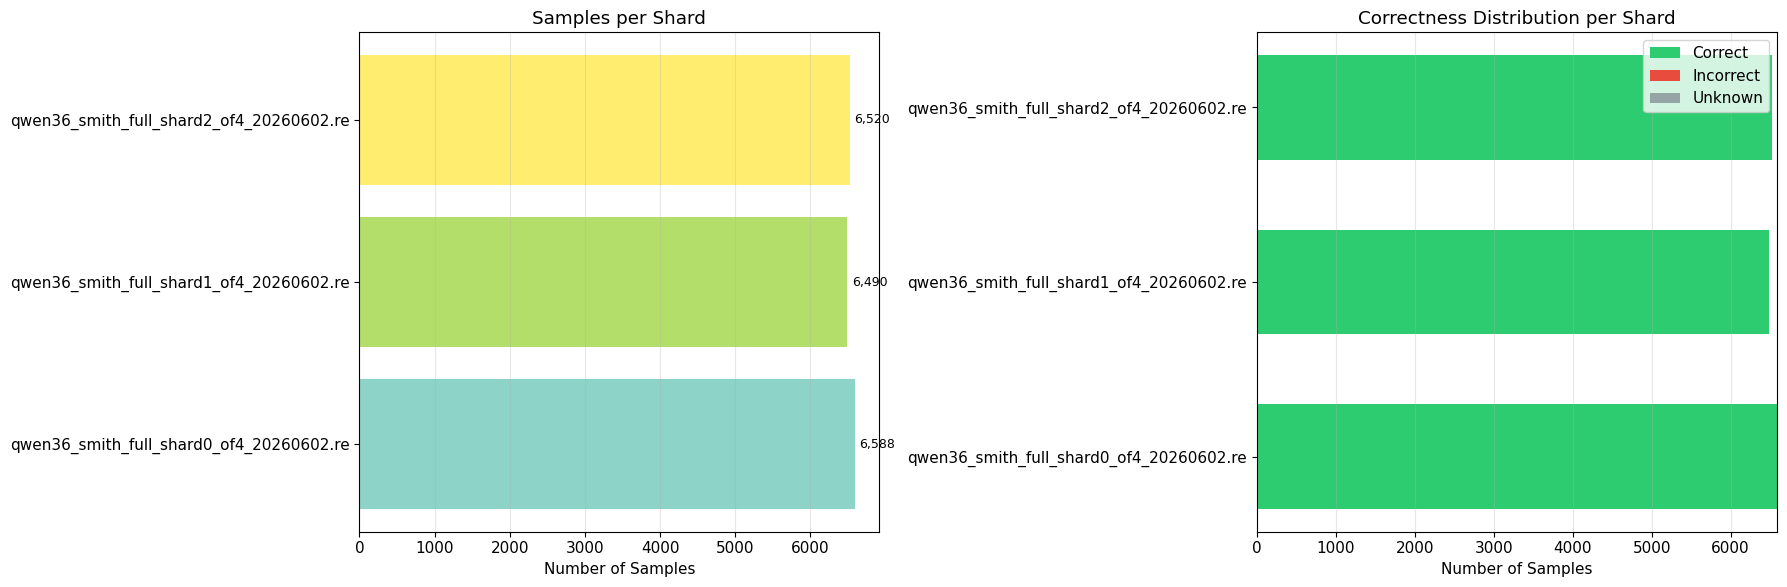

In [10]:
# Visualize: Samples per shard (bar chart)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: samples per shard
shard_names = [r['Shard'][:40] for r in shard_summary_rows]
shard_counts = [r['#Trajectories'] for r in shard_summary_rows]
colors = plt.cm.Set3(np.linspace(0, 1, len(shard_names)))

axes[0].barh(shard_names, shard_counts, color=colors)
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('Samples per Shard')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(shard_counts):
    axes[0].text(v + max(shard_counts)*0.01, i, f'{v:,}', va='center', fontsize=9)

# Right: correctness distribution (stacked bar)
correct_counts = [r['#Correct'] for r in shard_summary_rows]
incorrect_counts = [r['#Incorrect'] for r in shard_summary_rows]
unknown_counts = [r['#Unknown'] for r in shard_summary_rows]

x = np.arange(len(shard_names))
width = 0.6
axes[1].barh(x, correct_counts, width, label='Correct', color='#2ecc71')
axes[1].barh(x, incorrect_counts, width, left=correct_counts, label='Incorrect', color='#e74c3c')
left_for_unknown = [c + i for c, i in zip(correct_counts, incorrect_counts)]
axes[1].barh(x, unknown_counts, width, left=left_for_unknown, label='Unknown', color='#95a5a6')
axes[1].set_yticks(x)
axes[1].set_yticklabels(shard_names)
axes[1].set_xlabel('Number of Samples')
axes[1].set_title('Correctness Distribution per Shard')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Top repos by number of trajectories
repo_total_counts = Counter()
for sample in all_data:
    repo_total_counts[sample['repo']] += 1

TOP_N = 30
top_repos = repo_total_counts.most_common(TOP_N)

print(f'Top {TOP_N} repos by number of trajectories:')
print('=' * 80)
print(f'{"Repo":<50} {"#Trajectories":>14}')
print('-' * 80)
for repo, count in top_repos:
    print(f'{repo:<50} {count:>14,}')
print('=' * 80)
print(f'Total unique repos: {len(repo_total_counts):,}')

Top 30 repos by number of trajectories:
Repo                                                #Trajectories
--------------------------------------------------------------------------------
scanny/python-pptx                                          1,068
sqlfluff/sqlfluff                                             779
python-openxml/python-docx                                    768
cantools/cantools                                             757
pylint-dev/astroid                                            741
pygments/pygments                                             659
pydicom/pydicom                                               629
seperman/deepdiff                                             610
pallets/jinja                                                 569
conan-io/conan                                                498
tobymao/sqlglot                                               487
oauthlib/oauthlib                                             436
python-trio/trio     

In [12]:
# Model distribution
model_counts = Counter(s['model'] for s in all_data)
print('Model distribution:')
print('=' * 60)
for model, count in model_counts.most_common():
    pct = count / len(all_data) * 100
    print(f'  {model:<40} {count:>8,} ({pct:.1f}%)')
print('=' * 60)

Model distribution:
  openai/Qwen3-Coder-Next                    19,598 (100.0%)


## 5. Token Length Distribution Analysis

In [13]:
# Compute token statistics per shard and per repo
shard_token_stats = defaultdict(lambda: {'total': [], 'system': [], 'user': [], 'assistant': []})
repo_token_stats = defaultdict(lambda: {'total': [], 'system': [], 'user': [], 'assistant': []})

for sample in all_data:
    shard = sample['shard_name']
    repo = sample['repo']
    msg_info = sample['msg_token_info']
    
    total_tokens = sum(t for _, t in msg_info)
    system_tokens = sum(t for r, t in msg_info if r == 'system')
    user_tokens = sum(t for r, t in msg_info if r == 'user')
    assistant_tokens = sum(t for r, t in msg_info if r == 'assistant')
    
    shard_token_stats[shard]['total'].append(total_tokens)
    shard_token_stats[shard]['system'].append(system_tokens)
    shard_token_stats[shard]['user'].append(user_tokens)
    shard_token_stats[shard]['assistant'].append(assistant_tokens)
    
    repo_token_stats[repo]['total'].append(total_tokens)
    repo_token_stats[repo]['system'].append(system_tokens)
    repo_token_stats[repo]['user'].append(user_tokens)
    repo_token_stats[repo]['assistant'].append(assistant_tokens)

print(f'Token stats computed for {len(shard_token_stats)} shards and {len(repo_token_stats)} repos.')

Token stats computed for 3 shards and 105 repos.


### 5.1 Per-Shard Token Length Summary Table

In [14]:
def compute_stats(values):
    """Compute mean, min, max for a list of values."""
    if not values:
        return 0, 0, 0
    return int(np.mean(values)), int(np.min(values)), int(np.max(values))

# Build DataFrame
rows = []
for shard in sorted(shard_token_stats.keys()):
    stats = shard_token_stats[shard]
    n = len(stats['total'])
    total_mean, total_min, total_max = compute_stats(stats['total'])
    sys_mean, sys_min, sys_max = compute_stats(stats['system'])
    user_mean, user_min, user_max = compute_stats(stats['user'])
    asst_mean, asst_min, asst_max = compute_stats(stats['assistant'])
    rows.append({
        'Shard': shard, 'N': n,
        'Total_Mean': total_mean, 'Total_Min': total_min, 'Total_Max': total_max,
        'System_Mean': sys_mean, 'System_Min': sys_min, 'System_Max': sys_max,
        'User_Mean': user_mean, 'User_Min': user_min, 'User_Max': user_max,
        'Assistant_Mean': asst_mean, 'Assistant_Min': asst_min, 'Assistant_Max': asst_max,
    })

df_shard = pd.DataFrame(rows)

print('Token Length Distribution per Shard (tokens per sample)')
print('=' * 160)
print(f'{"Shard":<55} {"N":>6} | {"Total":^21} | {"System":^21} | {"User":^21} | {"Assistant":^21}')
print(f'{"":<55} {"":>6} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7}')
print('-' * 160)
for _, row in df_shard.iterrows():
    shard_name = row['Shard'][:53]
    print(f'{shard_name:<55} {row["N"]:>6} | '
          f'{row["Total_Mean"]:>6,} {row["Total_Min"]:>6,} {row["Total_Max"]:>7,} | '
          f'{row["System_Mean"]:>6,} {row["System_Min"]:>6,} {row["System_Max"]:>7,} | '
          f'{row["User_Mean"]:>6,} {row["User_Min"]:>6,} {row["User_Max"]:>7,} | '
          f'{row["Assistant_Mean"]:>6,} {row["Assistant_Min"]:>6,} {row["Assistant_Max"]:>7,}')
print('=' * 160)

Token Length Distribution per Shard (tokens per sample)
Shard                                                        N |         Total         |        System         |         User          |       Assistant      
                                                               |   Mean    Min     Max |   Mean    Min     Max |   Mean    Min     Max |   Mean    Min     Max
----------------------------------------------------------------------------------------------------------------------------------------------------------------
qwen36_smith_full_shard0_of4_20260602.resolved.openai     6588 | 26,752  2,583 170,041 |     15     15      15 |    574    308   6,612 |      0      0       0
qwen36_smith_full_shard1_of4_20260602.resolved.openai     6490 | 26,913  3,157 245,524 |     15     15      15 |    572    330  13,077 |      0      0       0
qwen36_smith_full_shard2_of4_20260602.resolved.openai     6520 | 27,047  2,867 146,406 |     15     15      15 |    568    285   5,562 |      0    

In [15]:
# Display as styled DataFrame
display_df = df_shard.set_index('Shard')
# Rename columns for better display
col_map = {
    'N': ('Count', 'N'),
    'Total_Mean': ('Total', 'Mean'), 'Total_Min': ('Total', 'Min'), 'Total_Max': ('Total', 'Max'),
    'System_Mean': ('System', 'Mean'), 'System_Min': ('System', 'Min'), 'System_Max': ('System', 'Max'),
    'User_Mean': ('User', 'Mean'), 'User_Min': ('User', 'Min'), 'User_Max': ('User', 'Max'),
    'Assistant_Mean': ('Assistant', 'Mean'), 'Assistant_Min': ('Assistant', 'Min'), 'Assistant_Max': ('Assistant', 'Max'),
}
display_df.columns = pd.MultiIndex.from_tuples([col_map[c] for c in display_df.columns])
display_df

Count  Total                \
                                                       N   Mean   Min     Max   
Shard                                                                           
qwen36_smith_full_shard0_of4_20260602.resolved....  6588  26752  2583  170041   
qwen36_smith_full_shard1_of4_20260602.resolved....  6490  26913  3157  245524   
qwen36_smith_full_shard2_of4_20260602.resolved....  6520  27047  2867  146406   

                                                   System         User       \
                                                     Mean Min Max Mean  Min   
Shard                                                                         
qwen36_smith_full_shard0_of4_20260602.resolved....     15  15  15  574  308   
qwen36_smith_full_shard1_of4_20260602.resolved....     15  15  15  572  330   
qwen36_smith_full_shard2_of4_20260602.resolved....     15  15  15  568  285   

                                                          Assistant          
                                                      Max      Mean Min Max  
Shard                                                                        
qwen36_smith_full_shard0_of4_20260602.resolved....   6612         0   0   0  
qwen36_smith_full_shard1_of4_20260602.resolved....  13077         0   0   0  
qwen36_smith_full_shard2_of4_20260602.resolved....   5562         0   0   0

### 5.2 Token Length Distribution Visualization

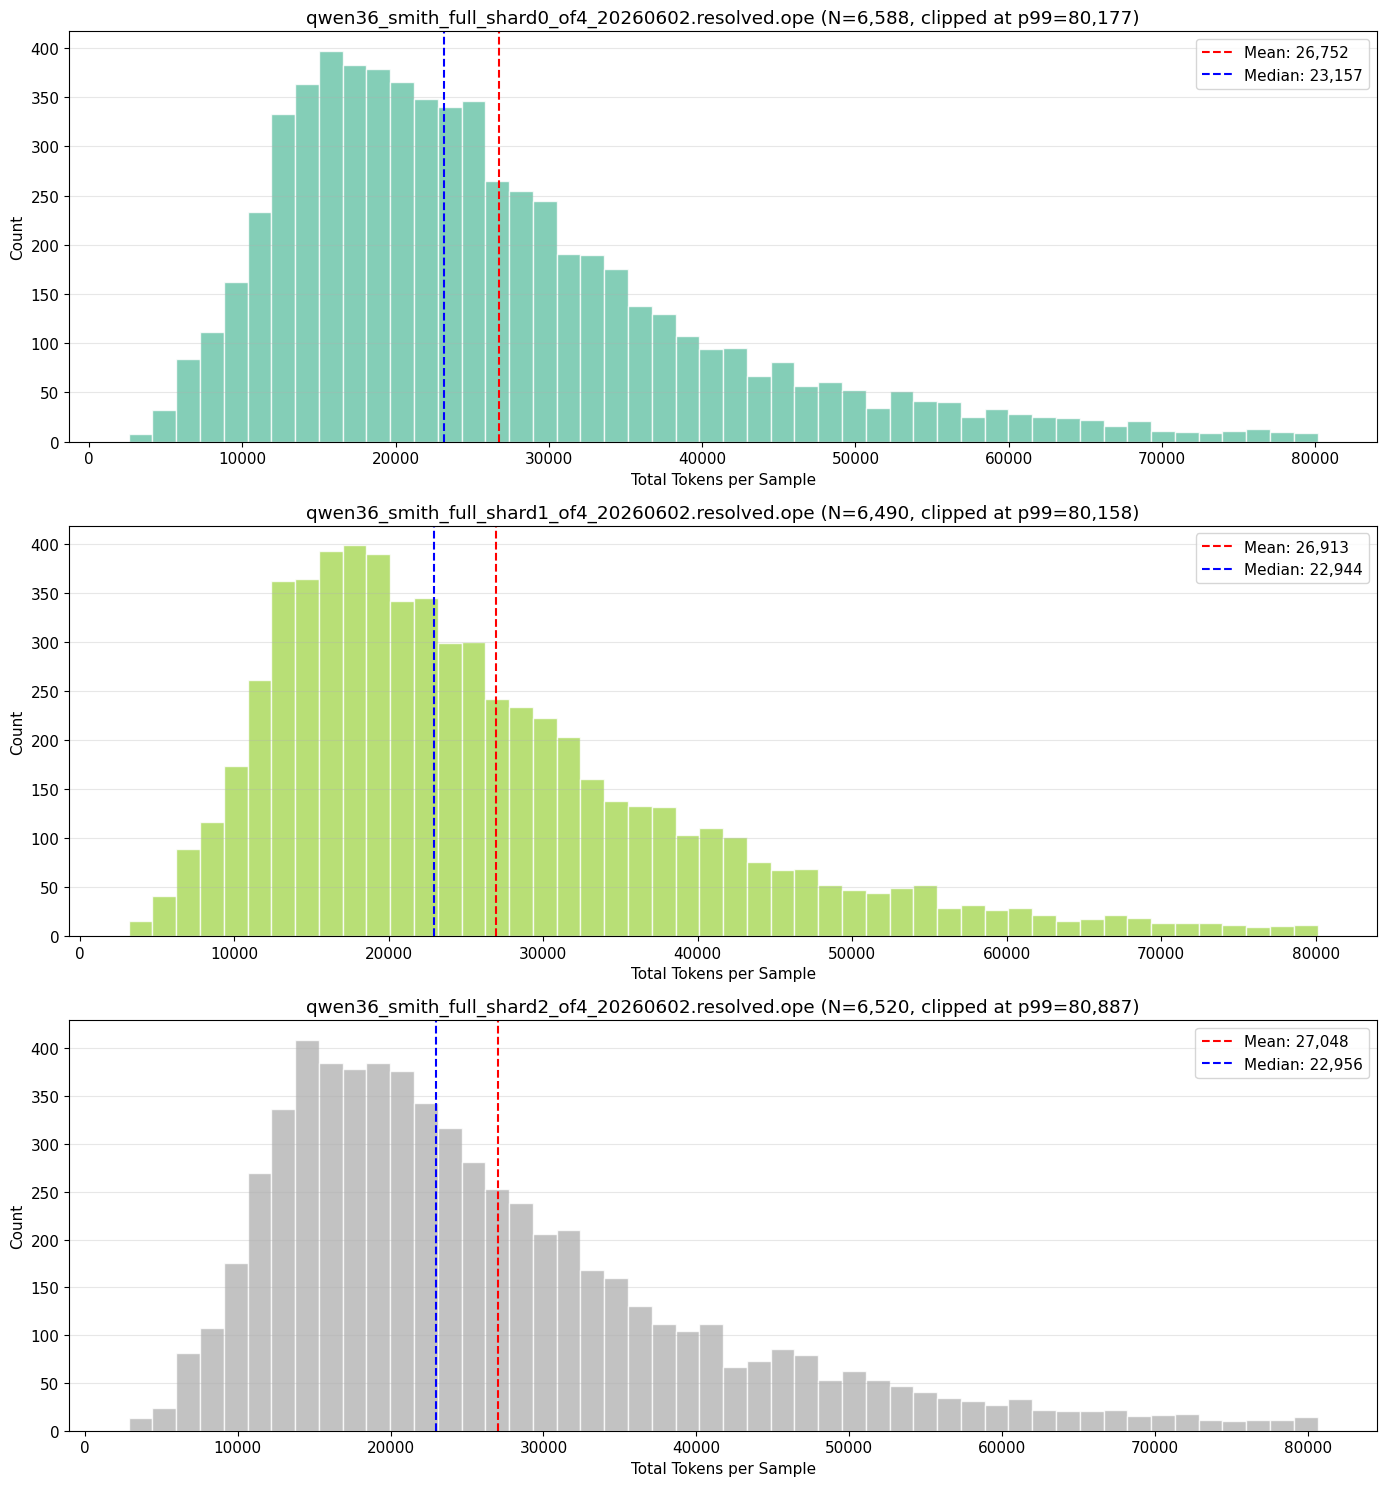

In [16]:
# Histogram: Total token length distribution per shard
n_shards = len(shard_token_stats)
fig, axes = plt.subplots(n_shards, 1, figsize=(14, 5 * n_shards), squeeze=False)

for idx, shard in enumerate(sorted(shard_token_stats.keys())):
    ax = axes[idx, 0]
    data = shard_token_stats[shard]['total']
    
    # Clip at 99th percentile for better visualization
    p99 = np.percentile(data, 99)
    clipped = [x for x in data if x <= p99]
    
    ax.hist(clipped, bins=50, color=plt.cm.Set2(idx / max(n_shards - 1, 1)), 
            edgecolor='white', alpha=0.8)
    ax.axvline(np.mean(data), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {np.mean(data):,.0f}')
    ax.axvline(np.median(data), color='blue', linestyle='--', linewidth=1.5, label=f'Median: {np.median(data):,.0f}')
    ax.set_xlabel('Total Tokens per Sample')
    ax.set_ylabel('Count')
    ax.set_title(f'{shard[:50]} (N={len(data):,}, clipped at p99={p99:,.0f})')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1559589/1419539644.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, vert=False, labels=labels, patch_artist=True,


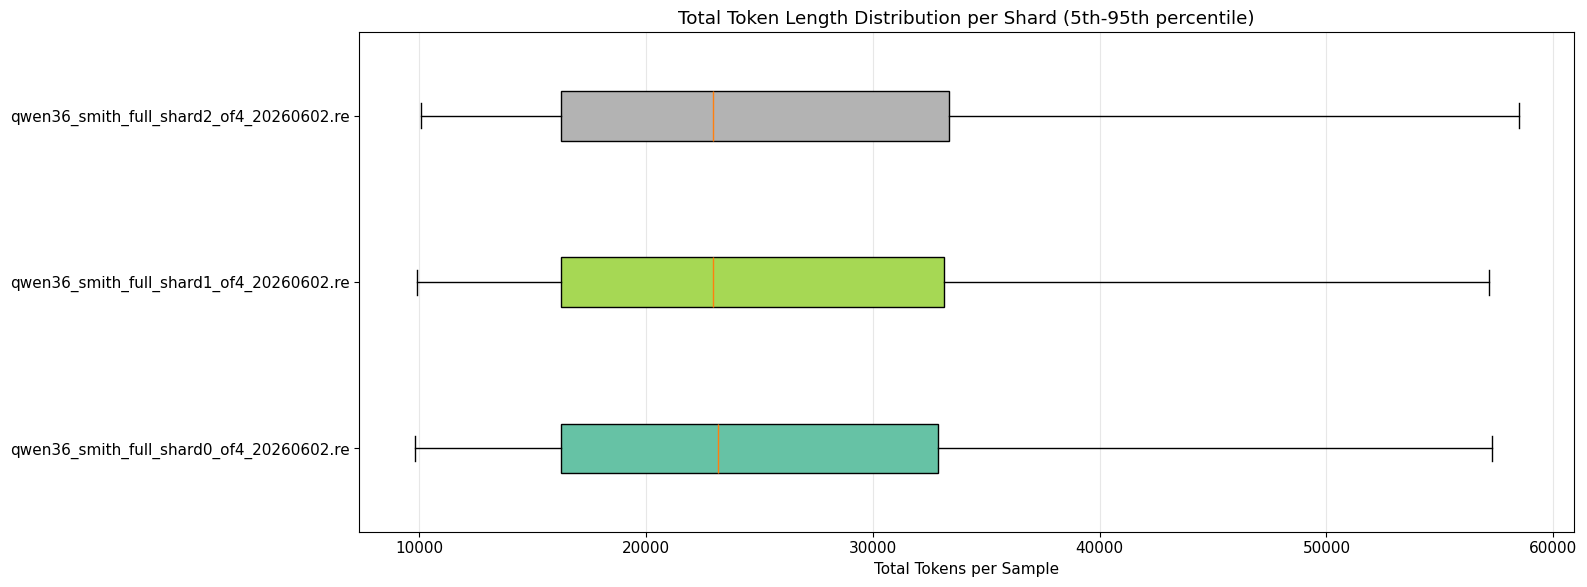

In [17]:
# Box plot: Token distribution comparison across shards
fig, ax = plt.subplots(figsize=(16, 6))

shard_names_sorted = sorted(shard_token_stats.keys())
data_to_plot = [shard_token_stats[s]['total'] for s in shard_names_sorted]
labels = [s[:40] for s in shard_names_sorted]

bp = ax.boxplot(data_to_plot, vert=False, labels=labels, patch_artist=True, 
                showfliers=False, whis=[5, 95])
colors_bp = plt.cm.Set2(np.linspace(0, 1, len(labels)))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)

ax.set_xlabel('Total Tokens per Sample')
ax.set_title('Total Token Length Distribution per Shard (5th-95th percentile)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

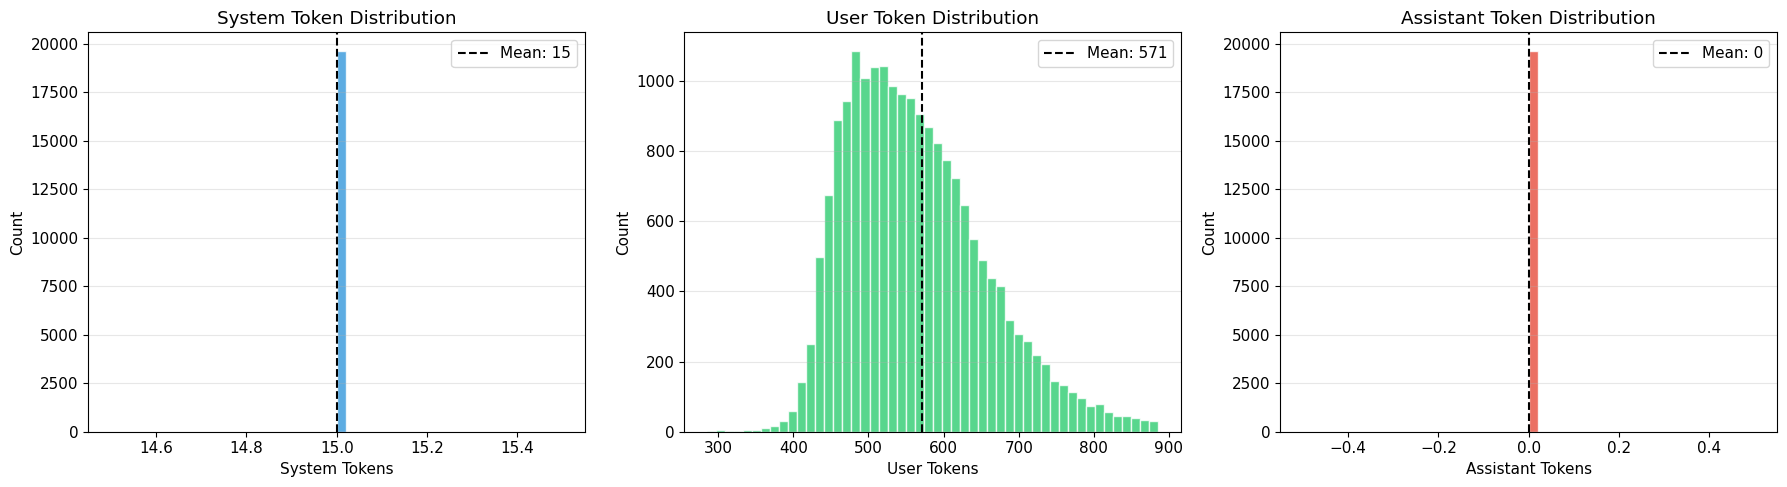

In [18]:
# Per-role token distribution (stacked area or grouped bar)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

roles = ['system', 'user', 'assistant']
role_colors = {'system': '#3498db', 'user': '#2ecc71', 'assistant': '#e74c3c'}

for idx, role in enumerate(roles):
    ax = axes[idx]
    all_role_tokens = []
    for shard in shard_names_sorted:
        all_role_tokens.extend(shard_token_stats[shard][role])
    
    # Clip at 99th percentile
    if all_role_tokens:
        p99 = np.percentile(all_role_tokens, 99)
        clipped = [x for x in all_role_tokens if x <= p99]
        ax.hist(clipped, bins=50, color=role_colors[role], edgecolor='white', alpha=0.8)
        ax.axvline(np.mean(all_role_tokens), color='black', linestyle='--', 
                   linewidth=1.5, label=f'Mean: {np.mean(all_role_tokens):,.0f}')
    
    ax.set_xlabel(f'{role.capitalize()} Tokens')
    ax.set_ylabel('Count')
    ax.set_title(f'{role.capitalize()} Token Distribution')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Per-Repo Token Length Analysis (Top Repos)

In [19]:
# Top repos by sample count - token stats
TOP_N_VIS = 20
top_repos_vis = [repo for repo, _ in repo_total_counts.most_common(TOP_N_VIS)]

# Summary table for top repos
print(f'Token Length Distribution - Top {TOP_N_VIS} Repos')
print('=' * 130)
print(f'{"Repo":<40} {"N":>6} | {"Total":^21} | {"System":^21} | {"User":^21} | {"Assistant":^21}')
print(f'{"":<40} {"":>6} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7} | {"Mean":>6} {"Min":>6} {"Max":>7}')
print('-' * 130)
for repo in top_repos_vis:
    stats = repo_token_stats[repo]
    n = len(stats['total'])
    total_mean, total_min, total_max = compute_stats(stats['total'])
    sys_mean, sys_min, sys_max = compute_stats(stats['system'])
    user_mean, user_min, user_max = compute_stats(stats['user'])
    asst_mean, asst_min, asst_max = compute_stats(stats['assistant'])
    repo_display = str(repo)[:38]
    print(f'{repo_display:<40} {n:>6} | '
          f'{total_mean:>6,} {total_min:>6,} {total_max:>7,} | '
          f'{sys_mean:>6,} {sys_min:>6,} {sys_max:>7,} | '
          f'{user_mean:>6,} {user_min:>6,} {user_max:>7,} | '
          f'{asst_mean:>6,} {asst_min:>6,} {asst_max:>7,}')
print('=' * 130)

Token Length Distribution - Top 20 Repos
Repo                                          N |         Total         |        System         |         User          |       Assistant      
                                                |   Mean    Min     Max |   Mean    Min     Max |   Mean    Min     Max |   Mean    Min     Max
----------------------------------------------------------------------------------------------------------------------------------
scanny/python-pptx                         1068 | 27,823  4,061  87,568 |     15     15      15 |    548    378     874 |      0      0       0
sqlfluff/sqlfluff                           779 | 36,888  5,880 136,683 |     15     15      15 |    563    385   6,237 |      0      0       0
python-openxml/python-docx                  768 | 25,920  6,183  78,923 |     15     15      15 |    525    378     785 |      0      0       0
cantools/cantools                           757 | 31,001  4,410 154,565 |     15     15      15 |    567    

/tmp/ipykernel_1559589/483194474.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, vert=False, labels=repo_labels, patch_artist=True,


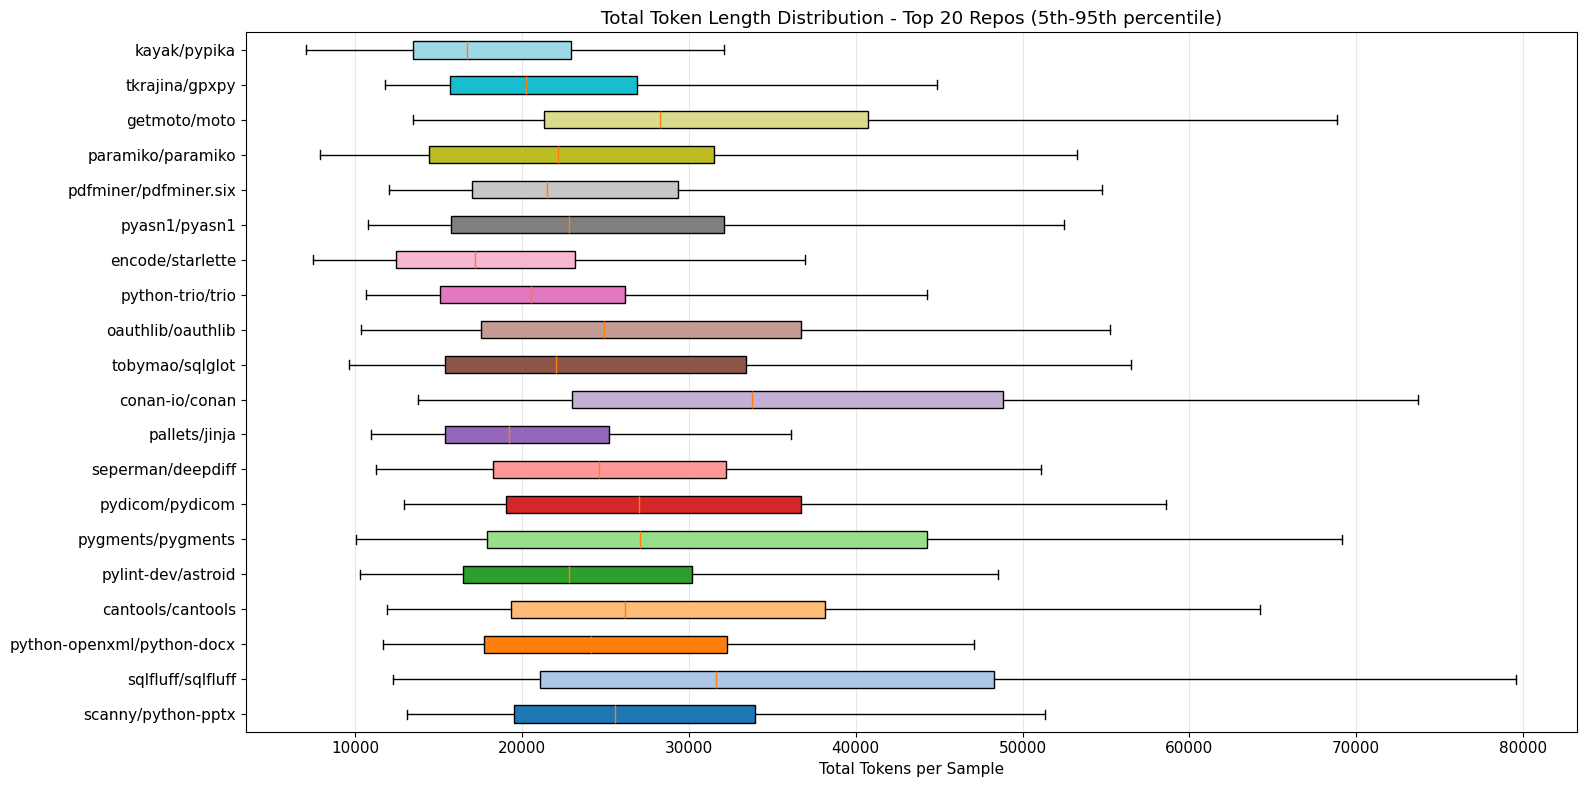

In [20]:
# Box plot: Token distribution for top repos
fig, ax = plt.subplots(figsize=(16, 8))
data_to_plot = [repo_token_stats[repo]['total'] for repo in top_repos_vis]
repo_labels = [str(r)[:40] for r in top_repos_vis]

bp = ax.boxplot(data_to_plot, vert=False, labels=repo_labels, patch_artist=True, 
                showfliers=False, whis=[5, 95])
colors_bp = plt.cm.tab20(np.linspace(0, 1, TOP_N_VIS))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)
ax.set_xlabel('Total Tokens per Sample')
ax.set_title(f'Total Token Length Distribution - Top {TOP_N_VIS} Repos (5th-95th percentile)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.4 Overall Statistics Summary

In [21]:
# Overall statistics
all_total_tokens = []
all_system_tokens = []
all_user_tokens = []
all_assistant_tokens = []
all_num_messages = []

for sample in all_data:
    msg_info = sample['msg_token_info']
    total = sum(t for _, t in msg_info)
    system = sum(t for r, t in msg_info if r == 'system')
    user = sum(t for r, t in msg_info if r == 'user')
    assistant = sum(t for r, t in msg_info if r == 'assistant')
    
    all_total_tokens.append(total)
    all_system_tokens.append(system)
    all_user_tokens.append(user)
    all_assistant_tokens.append(assistant)
    all_num_messages.append(len(msg_info))

print('=' * 80)
print('OVERALL DATASET STATISTICS')
print('=' * 80)
print(f'Total samples: {len(all_data):,}')
print(f'Total unique repos: {len(repo_total_counts):,}')
print(f'Total shards: {len(shard_token_stats)}')
print()
print(f'Messages per sample:  Mean={np.mean(all_num_messages):.1f}  '
      f'Min={np.min(all_num_messages)}  Max={np.max(all_num_messages)}  '
      f'Median={np.median(all_num_messages):.0f}')
print()
print(f'Total tokens/sample:  Mean={np.mean(all_total_tokens):,.0f}  '
      f'Min={np.min(all_total_tokens):,}  Max={np.max(all_total_tokens):,}  '
      f'Median={np.median(all_total_tokens):,.0f}')
print(f'System tokens/sample: Mean={np.mean(all_system_tokens):,.0f}  '
      f'Min={np.min(all_system_tokens):,}  Max={np.max(all_system_tokens):,}  '
      f'Median={np.median(all_system_tokens):,.0f}')
print(f'User tokens/sample:   Mean={np.mean(all_user_tokens):,.0f}  '
      f'Min={np.min(all_user_tokens):,}  Max={np.max(all_user_tokens):,}  '
      f'Median={np.median(all_user_tokens):,.0f}')
print(f'Asst tokens/sample:   Mean={np.mean(all_assistant_tokens):,.0f}  '
      f'Min={np.min(all_assistant_tokens):,}  Max={np.max(all_assistant_tokens):,}  '
      f'Median={np.median(all_assistant_tokens):,.0f}')
print('=' * 80)

OVERALL DATASET STATISTICS
Total samples: 19,598
Total unique repos: 105
Total shards: 3

Messages per sample:  Mean=67.3  Min=16  Max=430  Median=56

Total tokens/sample:  Mean=26,904  Min=2,583  Max=245,524  Median=23,016
System tokens/sample: Mean=15  Min=15  Max=15  Median=15
User tokens/sample:   Mean=571  Min=285  Max=13,077  Median=551
Asst tokens/sample:   Mean=0  Min=0  Max=0  Median=0
